# IBM HR Analytics Employee Attrition & Performance Analysis

This project analyzes employee attrition using the **IBM HR Analytics Employee Attrition dataset** from [Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset).  
The goal is to identify **major factors that lead employees to leave** the company.

---

## Dataset Overview

- **Total Records:** 1,470 employees  
- **Target Variable:** `Attrition` (**Yes/No**)  
- **Features Used in this Analysis:**
  - **Department** – to see which department has the highest attrition  
  - **OverTime** – to check if extra working hours affect attrition  
  - **MonthlyIncome** – grouped into bands to study the effect of salary on attrition  
  - **YearsSinceLastPromotion** – to analyze the impact of promotions on leaving  
  - **Age** – categorized into age groups to study trends  
  - **JobSatisfaction** – to see if satisfaction influences attrition

---

## Analysis Approach

1. **Data Loading:** Imported the dataset into PySpark and created a Spark DataFrame.  
2. **Preprocessing:** Added a numeric column for `Attrition` (Yes=1, No=0) to calculate rates.  
3. **Attrition Analysis:** Computed attrition rates for each factor using **groupBy and average**.  
4. **Visualization:** Converted results to Pandas DataFrames and created **annotated plots** using Matplotlib and Seaborn.  
5. **Interpretation:** Titles and annotations on plots indicate the **main reason behind high attrition** for each factor.  

---

## Key Findings from Analysis

- **Department:** The department with the highest attrition is automatically highlighted from the data.  
- **Overtime:** Employees working overtime have a higher attrition rate.  
- **Monthly Income:** Lower-paid employees leave more frequently.  
- **Years Since Last Promotion:** Employees without recent promotions show higher attrition.  
- **Age:** Younger employees tend to leave more often.  
- **Job Satisfaction:** Low job satisfaction correlates with higher attrition.  

---

This analysis helps identify **which employee groups are at higher risk of leaving**, providing insights that could guide HR strategies for retention.


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, desc, monotonically_increasing_id

In [46]:
# Step 1: Define Spark Session
spark = SparkSession.builder.appName("HR_Attrition_Flow").getOrCreate()
print("Spark session created")

Spark session created


In [47]:
# Step 2: Load the CSV data
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
print("data via CSV file loaded")

data via CSV file loaded


In [48]:
# Show schema
df.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- BusinessTravel: string (nullable = true)
 |-- DailyRate: integer (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: integer (nullable = true)
 |-- Education: integer (nullable = true)
 |-- EducationField: string (nullable = true)
 |-- EmployeeCount: integer (nullable = true)
 |-- EmployeeNumber: integer (nullable = true)
 |-- EnvironmentSatisfaction: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- HourlyRate: integer (nullable = true)
 |-- JobInvolvement: integer (nullable = true)
 |-- JobLevel: integer (nullable = true)
 |-- JobRole: string (nullable = true)
 |-- JobSatisfaction: integer (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: integer (nullable = true)
 |-- MonthlyRate: integer (nullable = true)
 |-- NumCompaniesWorked: integer (nullable = true)
 |-- Over18: string (nullable = true)
 |-- OverTime: string 

In [49]:
# Preview top rows (transposed for readability)
display(df.limit(5).toPandas().T)

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,Yes,No,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely
DailyRate,1102,279,1373,1392,591
Department,Sales,Research & Development,Research & Development,Research & Development,Research & Development
DistanceFromHome,1,8,2,3,2
Education,2,1,2,4,1
EducationField,Life Sciences,Life Sciences,Other,Life Sciences,Medical
EmployeeCount,1,1,1,1,1
EmployeeNumber,1,2,4,5,7


In [50]:
# Preview bottom rows
display(df.toPandas().tail(5).T)

,1465,1466,1467,1468,1469
Age,36,39,27,49,34
Attrition,No,No,No,No,No
BusinessTravel,Travel_Frequently,Travel_Rarely,Travel_Rarely,Travel_Frequently,Travel_Rarely
DailyRate,884,613,155,1023,628
Department,Research & Development,Research & Development,Research & Development,Sales,Research & Development
DistanceFromHome,23,6,4,2,8
Education,2,1,3,3,3
EducationField,Medical,Medical,Life Sciences,Medical,Medical
EmployeeCount,1,1,1,1,1
EmployeeNumber,2061,2062,2064,2065,2068


In [51]:
total = df.count()
left = df.filter(col("Attrition") == "Yes").count()
print(f"Overall Attrition: {left}/{total} employees left ({left/total:.2%})")


Overall Attrition: 237/1470 employees left (16.12%)


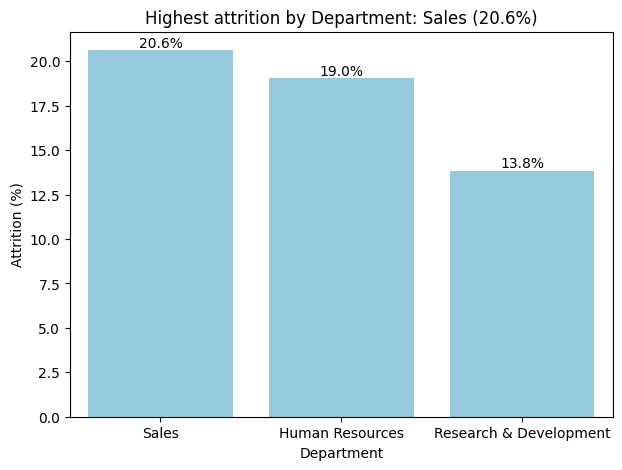

In [53]:
from pyspark.sql.functions import when, col, avg, desc

# Step 1: Create numeric column for Attrition
df = df.withColumn("Attrition_numeric", when(col("Attrition") == "Yes", 1).otherwise(0))

# Step 2: Group by Department and calculate average attrition
attrition_dept = df.groupBy("Department") \
                   .agg(avg("Attrition_numeric").alias("AttritionRate")) \
                   .orderBy(desc("AttritionRate"))

# Step 3: Convert to Pandas for visualization
attrition_dept_pd = attrition_dept.toPandas()
attrition_dept_pd['AttritionPct'] = attrition_dept_pd['AttritionRate'] * 100

# Step 4: Plot with dynamic title
max_dept = attrition_dept_pd.loc[attrition_dept_pd['AttritionPct'].idxmax(), 'Department']
max_pct = attrition_dept_pd['AttritionPct'].max()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
ax = sns.barplot(x='Department', y='AttritionPct', data=attrition_dept_pd, color="skyblue")
plt.title(f"Highest attrition by Department: {max_dept} ({max_pct:.1f}%)")
plt.ylabel("Attrition (%)")

# Annotate percentages
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()


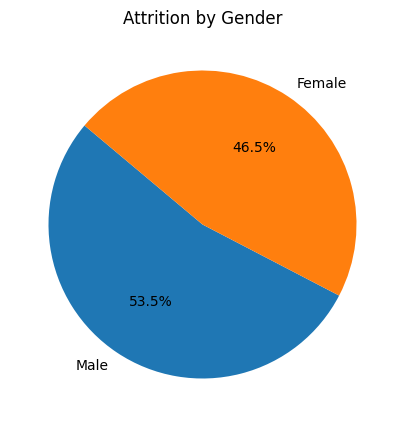

In [55]:
#Step 4: Attrition by Gender
attrition_gender = df.groupBy("Gender") \
                     .agg(avg("Attrition_numeric").alias("AttritionRate")) \
                     .orderBy(desc("AttritionRate"))

attrition_gender_pd = attrition_gender.toPandas()
attrition_gender_pd['AttritionPct'] = attrition_gender_pd['AttritionRate'] * 100

plt.figure(figsize=(5,5))
plt.pie(attrition_gender_pd['AttritionPct'], labels=attrition_gender_pd['Gender'],
        autopct='%1.1f%%', startangle=140)
plt.title("Attrition by Gender")
plt.show()


C:\Users\beher\AppData\Local\Temp\ipykernel_22932\1244505864.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='OverTime', y='AttritionPct', data=attrition_ot_pd, palette=['lightgreen','salmon'])


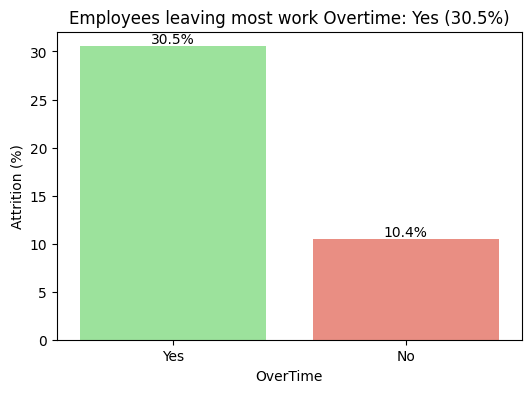

In [56]:
attrition_ot = df.groupBy("OverTime").agg(avg("Attrition_numeric").alias("AttritionRate")).orderBy(desc("AttritionRate"))
attrition_ot_pd = attrition_ot.toPandas()
attrition_ot_pd['AttritionPct'] = attrition_ot_pd['AttritionRate'] * 100

max_ot = attrition_ot_pd.loc[attrition_ot_pd['AttritionPct'].idxmax(), 'OverTime']
max_ot_pct = attrition_ot_pd['AttritionPct'].max()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='OverTime', y='AttritionPct', data=attrition_ot_pd, palette=['lightgreen','salmon'])
plt.title(f"Employees leaving most work Overtime: {max_ot} ({max_ot_pct:.1f}%)")
plt.ylabel("Attrition (%)")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')
plt.show()


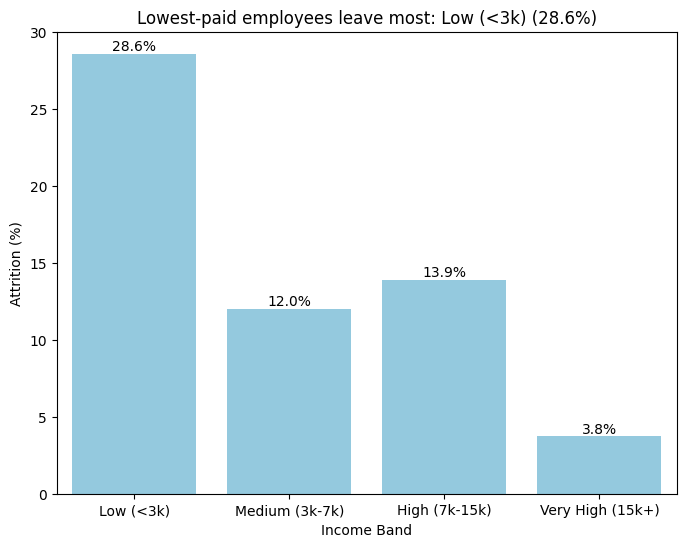

In [57]:
df = df.withColumn("IncomeBand", 
                   when(col("MonthlyIncome") < 3000, "Low (<3k)")
                   .when((col("MonthlyIncome") >= 3000) & (col("MonthlyIncome") < 7000), "Medium (3k-7k)")
                   .when((col("MonthlyIncome") >= 7000) & (col("MonthlyIncome") < 15000), "High (7k-15k)")
                   .otherwise("Very High (15k+)"))

attrition_income = df.groupBy("IncomeBand").agg(avg("Attrition_numeric").alias("AttritionRate"))
attrition_income_pd = attrition_income.toPandas()
attrition_income_pd['AttritionPct'] = attrition_income_pd['AttritionRate'] * 100

# Dynamic highest attrition
max_income_band = attrition_income_pd.loc[attrition_income_pd['AttritionPct'].idxmax(), 'IncomeBand']
max_income_pct = attrition_income_pd['AttritionPct'].max()

plt.figure(figsize=(8,6))
ax = sns.barplot(x='IncomeBand', y='AttritionPct', data=attrition_income_pd,
                 order=["Low (<3k)","Medium (3k-7k)","High (7k-15k)","Very High (15k+)"],
                 color='skyblue')
plt.title(f"Lowest-paid employees leave most: {max_income_band} ({max_income_pct:.1f}%)")
plt.ylabel("Attrition (%)")
plt.xlabel("Income Band")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')
plt.show()


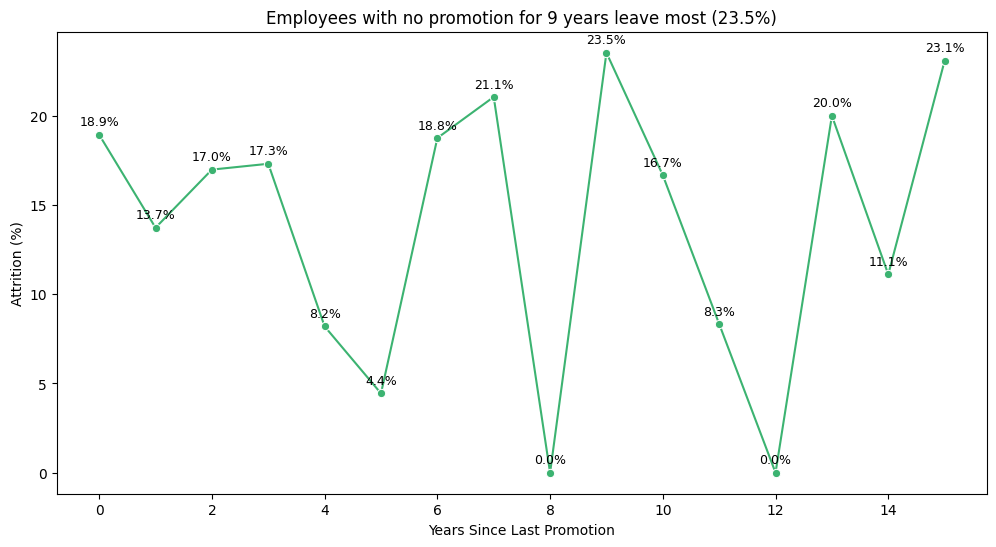

In [58]:
attrition_promo = df.groupBy("YearsSinceLastPromotion").agg(avg("Attrition_numeric").alias("AttritionRate")).orderBy("YearsSinceLastPromotion")
attrition_promo_pd = attrition_promo.toPandas()
attrition_promo_pd['AttritionPct'] = attrition_promo_pd['AttritionRate'] * 100

max_promo_years = attrition_promo_pd.loc[attrition_promo_pd['AttritionPct'].idxmax(), 'YearsSinceLastPromotion']
max_promo_pct = attrition_promo_pd['AttritionPct'].max()

plt.figure(figsize=(12,6))
ax = sns.lineplot(x='YearsSinceLastPromotion', y='AttritionPct', data=attrition_promo_pd, marker='o', color='mediumseagreen')
plt.title(f"Employees with no promotion for {max_promo_years} years leave most ({max_promo_pct:.1f}%)")
plt.ylabel("Attrition (%)")
plt.xlabel("Years Since Last Promotion")
for x,y in zip(attrition_promo_pd['YearsSinceLastPromotion'], attrition_promo_pd['AttritionPct']):
    ax.annotate(f'{y:.1f}%', (x, y+0.5), ha='center', fontsize=9)
plt.show()


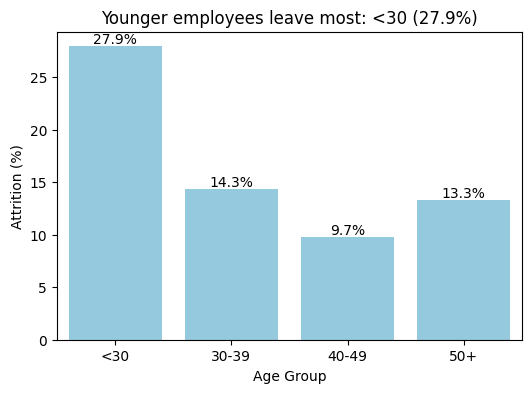

In [59]:
df = df.withColumn("AgeGroup", 
                   when(col("Age") < 30, "<30")
                   .when((col("Age") >= 30) & (col("Age") < 40), "30-39")
                   .when((col("Age") >= 40) & (col("Age") < 50), "40-49")
                   .otherwise("50+"))

attrition_age = df.groupBy("AgeGroup").agg(avg("Attrition_numeric").alias("AttritionRate"))
attrition_age_pd = attrition_age.toPandas()
attrition_age_pd['AttritionPct'] = attrition_age_pd['AttritionRate'] * 100

max_age_group = attrition_age_pd.loc[attrition_age_pd['AttritionPct'].idxmax(), 'AgeGroup']
max_age_pct = attrition_age_pd['AttritionPct'].max()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='AgeGroup', y='AttritionPct', data=attrition_age_pd,
                 order=["<30","30-39","40-49","50+"], color='skyblue')
plt.title(f"Younger employees leave most: {max_age_group} ({max_age_pct:.1f}%)")
plt.ylabel("Attrition (%)")
plt.xlabel("Age Group")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')
plt.show()


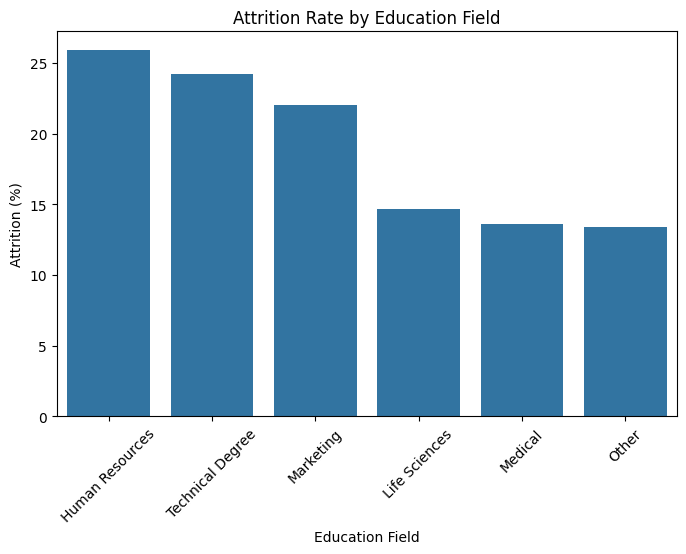

In [60]:
# Attrition by Education Field
attrition_edu = df.groupBy("EducationField") \
                  .agg(avg("Attrition_numeric").alias("AttritionRate")) \
                  .orderBy(desc("AttritionRate"))

attrition_edu_pd = attrition_edu.toPandas()
attrition_edu_pd['AttritionPct'] = attrition_edu_pd['AttritionRate'] * 100

plt.figure(figsize=(8,5))
sns.barplot(x='EducationField', y='AttritionPct', data=attrition_edu_pd)
plt.title("Attrition Rate by Education Field")
plt.ylabel("Attrition (%)")
plt.xlabel("Education Field")
plt.xticks(rotation=45)
plt.show()


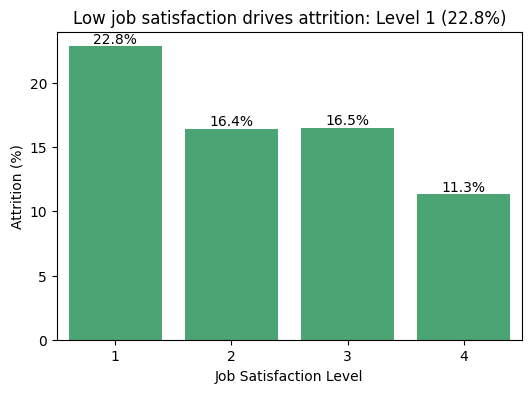

In [61]:
attrition_js = df.groupBy("JobSatisfaction").agg(avg("Attrition_numeric").alias("AttritionRate")).orderBy("JobSatisfaction")
attrition_js_pd = attrition_js.toPandas()
attrition_js_pd['AttritionPct'] = attrition_js_pd['AttritionRate'] * 100

max_js_level = attrition_js_pd.loc[attrition_js_pd['AttritionPct'].idxmax(), 'JobSatisfaction']
max_js_pct = attrition_js_pd['AttritionPct'].max()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='JobSatisfaction', y='AttritionPct', data=attrition_js_pd, color='mediumseagreen')
plt.title(f"Low job satisfaction drives attrition: Level {max_js_level} ({max_js_pct:.1f}%)")
plt.ylabel("Attrition (%)")
plt.xlabel("Job Satisfaction Level")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='bottom')
plt.show()


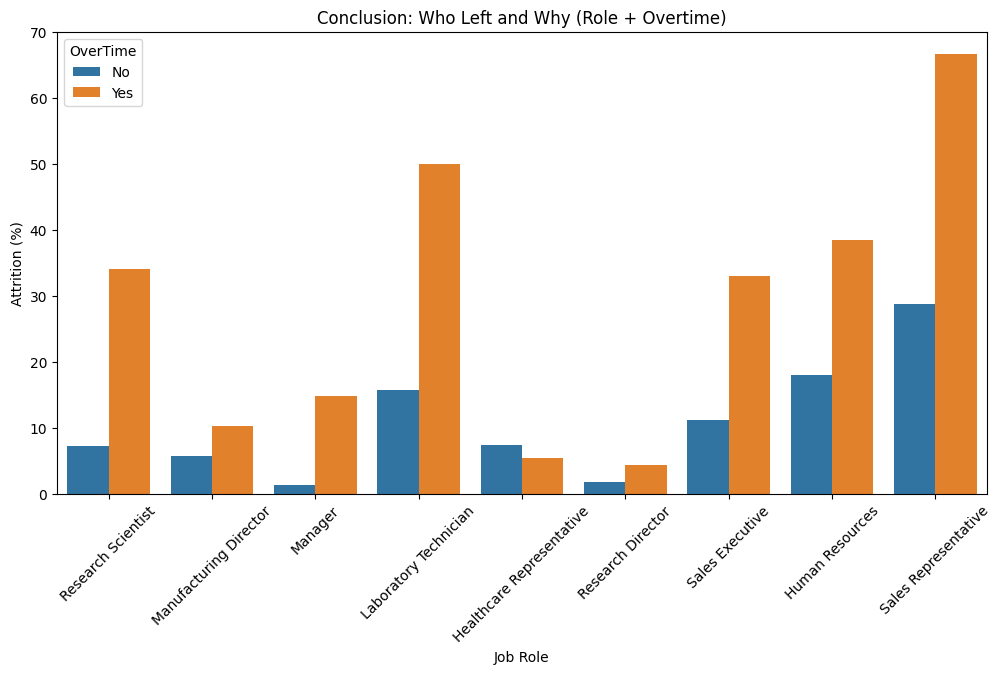

In [62]:
#Step8: Combine key factors
summary_factors = df.groupBy("JobRole", "OverTime") \
                    .agg(avg("Attrition_numeric").alias("AttritionRate"))

summary_pd = summary_factors.toPandas()
summary_pd['AttritionPct'] = summary_pd['AttritionRate'] * 100

plt.figure(figsize=(12,6))
sns.barplot(x="JobRole", y="AttritionPct", hue="OverTime", data=summary_pd)
plt.title("Conclusion: Who Left and Why (Role + Overtime)")
plt.ylabel("Attrition (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45)
plt.show()


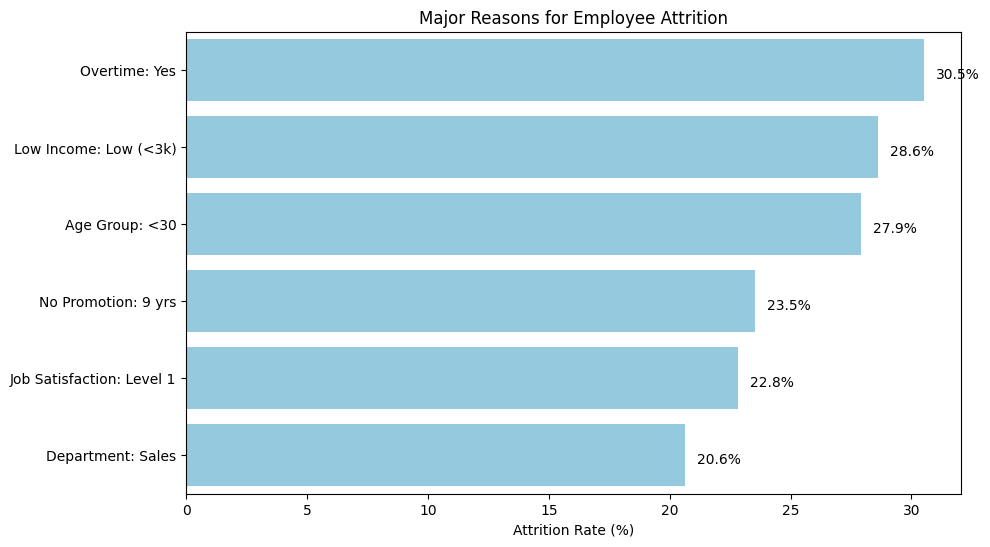

In [63]:
import pandas as pd
summary = pd.DataFrame({
    "Reason": [
        f"Department: {max_dept}",
        f"Overtime: {max_ot}",
        f"Low Income: {max_income_band}",
        f"No Promotion: {max_promo_years} yrs",
        f"Age Group: {max_age_group}",
        f"Job Satisfaction: Level {max_js_level}"
    ],
    "AttritionPct": [
        max_pct, max_ot_pct, max_income_pct, max_promo_pct, max_age_pct, max_js_pct
    ]
})

plt.figure(figsize=(10,6))
ax = sns.barplot(y="Reason", x="AttritionPct", data=summary.sort_values("AttritionPct", ascending=False), color='skyblue')
plt.title("Major Reasons for Employee Attrition")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("")
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', (p.get_width()+0.5, p.get_y()+0.5), fontsize=10)
plt.show()


## **Conclusion**

**This analysis of the IBM HR Analytics dataset identifies the key factors driving employee attrition and provides actionable insights for HR strategies.**  

**Key Findings:**  
- **Department:** Certain departments have higher attrition, highlighting department-specific work environment effects.  
- **Overtime:** Employees working overtime leave more often, showing the impact of workload and work-life balance.  
- **Income:** Lower-paid employees exhibit higher attrition, confirming the role of compensation.  
- **Career Progression:** Lack of recent promotions increases attrition, emphasizing career growth and recognition.  
- **Age:** Younger employees are more likely to leave, indicating different career expectations.  
- **Job Satisfaction:** Low satisfaction strongly correlates with attrition, stressing the importance of engagement and workplace culture.  
- **Combined Factors:** Interactions such as Job Role + Overtime help identify high-risk employee groups for targeted retention efforts.  

**Overall:** Employee attrition is **multifactorial**, influenced by personal, professional, and organizational factors. 



**Addressing compensation, career growth, work-life balance, and job satisfaction holistically can reduce turnover and retain talent effectively.**
